In [1]:
# The purpose of this project is to:
# show the energy budget and TS trends for each case to find quasi-steady state

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
# define eccentricity range

e_range =['e0','e01','e02','e03','e04']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.'+ e_range[i]+'_obl0.001/atm/hist/')

# define specific path

Path_TS        = []
Path_FSNT      = []
Path_FLNT      = []


for i in range(len(data_dir_file)):
    
    Path_TS.append(data_dir_file[i]+'TS_'+ e_range[i] +'_obl0.nc')
    Path_FSNT.append(data_dir_file[i]+'FSNT_'+ e_range[i] +'_obl0.nc')
    Path_FLNT.append(data_dir_file[i]+'FLNT_'+ e_range[i] +'_obl0.nc')
    
# Import data
# each file has 5 case elements

TS_obl0       =[]
FSNT_obl0     =[]
FLNT_obl0     =[]


for i in range(len(e_range)):
    TS_obl0.append(xr.open_mfdataset(Path_TS[i]))
    FSNT_obl0.append(xr.open_mfdataset(Path_FSNT[i]))
    FLNT_obl0.append(xr.open_mfdataset(Path_FLNT[i]))

In [3]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0,decode_times=False) #open the file and decode time as false

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

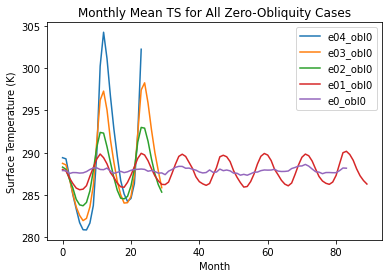

In [4]:
plt.plot(LatWeightAnyVar(TS_obl0[4].TS),label='e04_obl0')
plt.plot(LatWeightAnyVar(TS_obl0[3].TS),label='e03_obl0')
plt.plot(LatWeightAnyVar(TS_obl0[2].TS),label='e02_obl0')
plt.plot(LatWeightAnyVar(TS_obl0[1].TS),label='e01_obl0')
plt.plot(LatWeightAnyVar(TS_obl0[0].TS),label='e0_obl0')
plt.title('Monthly Mean TS for All Zero-Obliquity Cases')
plt.xlabel('Month')
plt.ylabel('Surface Temperature (K)')
plt.legend()

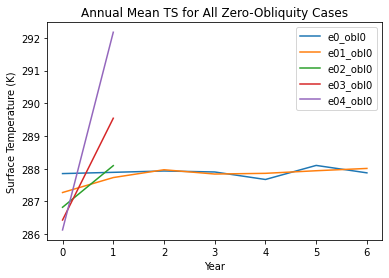

In [5]:
global_TS_obl0= [LatWeightAnyVar(TS_obl0[0].TS),
                    LatWeightAnyVar(TS_obl0[1].TS),
                    LatWeightAnyVar(TS_obl0[2].TS),
                    LatWeightAnyVar(TS_obl0[3].TS),
                    LatWeightAnyVar(TS_obl0[4].TS)]

sim_yr=[7,7,2,2,2]

annual_mean_global_TS_obl0=[[],[],[],[],[]]

for i in range(len(sim_yr)):
    for ii in range(sim_yr[i]):
        annual_mean_global_TS_obl0[i].append(np.mean(global_TS_obl0[i][ii*12:(ii+1)*12]))
    
    

plt.plot(annual_mean_global_TS_obl0[0],label='e0_obl0')
plt.plot(annual_mean_global_TS_obl0[1],label='e01_obl0')
plt.plot(annual_mean_global_TS_obl0[2],label='e02_obl0')
plt.plot(annual_mean_global_TS_obl0[3],label='e03_obl0')
plt.plot(annual_mean_global_TS_obl0[4],label='e04_obl0')

plt.title('Annual Mean TS for All Zero-Obliquity Cases')
plt.xlabel('Year')
plt.ylabel('Surface Temperature (K)')
plt.legend()



[None, None, None, None, None]


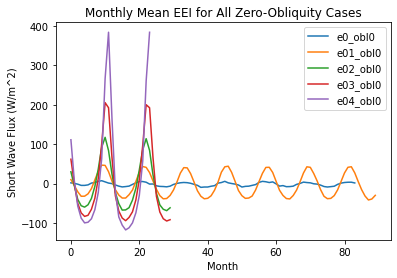

In [7]:
# EEI : Earth Energy Imbalance
EEI=[None] * 5

print(restom)

EEI[0]=LatWeightAnyVar(FSNT_obl0[0].FSNT)-LatWeightAnyVar(FLNT_obl0[0].FLNT)
EEI[1]=LatWeightAnyVar(FSNT_obl0[1].FSNT)-LatWeightAnyVar(FLNT_obl0[1].FLNT)
EEI[2]=LatWeightAnyVar(FSNT_obl0[2].FSNT)-LatWeightAnyVar(FLNT_obl0[2].FLNT)
EEI[3]=LatWeightAnyVar(FSNT_obl0[3].FSNT)-LatWeightAnyVar(FLNT_obl0[3].FLNT)
EEI[4]=LatWeightAnyVar(FSNT_obl0[4].FSNT)-LatWeightAnyVar(FLNT_obl0[4].FLNT)



plt.plot(EEI[0],label='e0_obl0')
plt.plot(EEI[1],label='e01_obl0')
plt.plot(EEI[2],label='e02_obl0')
plt.plot(EEI[3],label='e03_obl0')
plt.plot(EEI[4],label='e04_obl0')
plt.title('Monthly Mean EEI for All Zero-Obliquity Cases')
plt.xlabel('Month')
plt.ylabel('Short Wave Flux (W/m^2)')
plt.legend()



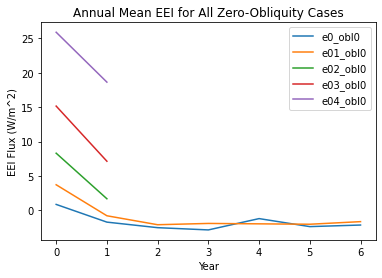

In [12]:
global_EEI_obl0    =[LatWeightAnyVar(FSNT_obl0[0].FSNT)-LatWeightAnyVar(FLNT_obl0[0].FLNT),
                     LatWeightAnyVar(FSNT_obl0[1].FSNT)-LatWeightAnyVar(FLNT_obl0[1].FLNT),
                     LatWeightAnyVar(FSNT_obl0[2].FSNT)-LatWeightAnyVar(FLNT_obl0[2].FLNT),
                     LatWeightAnyVar(FSNT_obl0[3].FSNT)-LatWeightAnyVar(FLNT_obl0[3].FLNT),
                     LatWeightAnyVar(FSNT_obl0[4].FSNT)-LatWeightAnyVar(FLNT_obl0[4].FLNT)]

sim_yr=[7,7,2,2,2]

annual_mean_global_EEI_obl0=[ [] for _ in range(5) ]

for i in range(len(sim_yr)):
    for ii in range(sim_yr[i]):
        annual_mean_global_EEI_obl0[i].append(np.mean(global_EEI_obl0[i][ii*12:(ii+1)*12]))
    
    

plt.plot(annual_mean_global_EEI_obl0[0],label='e0_obl0')
plt.plot(annual_mean_global_EEI_obl0[1],label='e01_obl0')
plt.plot(annual_mean_global_EEI_obl0[2],label='e02_obl0')
plt.plot(annual_mean_global_EEI_obl0[3],label='e03_obl0')
plt.plot(annual_mean_global_EEI_obl0[4],label='e04_obl0')

plt.title('Annual Mean EEI for All Zero-Obliquity Cases')
plt.xlabel('Year')
plt.ylabel('EEI Flux (W/m^2)')
plt.legend()
